In [1]:
import os
os.chdir('../../../..')

In [2]:
import json
import kmedoids 
import chemiscope
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.manifold import MDS, TSNE
from tqdm import tqdm
from pymatgen.io.ase import AseAtomsAdaptor
from pymatgen.core import Structure, Composition
from ase import Atoms
from collections import Counter
from sklearn.manifold import TSNE, MDS
from umap import UMAP

from src.datasets import MaterialsProject
from src.non_euclidean import Grassmann, Riemann, PersistentHomology, Wasserstein
from src.helper_functions import get_distances

In [3]:
mp = MaterialsProject()
mp.load()

mp.df = mp.df.with_columns(
    pl.col("formula_pretty")
    .map_elements(lambda x: Composition(x).weight, return_dtype=pl.Float64)
    .alias("weight")
)

2026-03-24 10:47:42.577 | INFO     | src.datasets:load:1020 - Loading cached Parquet data from data/Materials Project/stable_oxides.parquet...


In [4]:
mp.df

material_id,formula_pretty,energy_per_atom,formation_energy_per_atom,band_gap,is_metal,raw_structure,crystal_system,space_group,density,a,b,c,alpha,beta,gamma,volume,num_sites,soap_embedding,acsf_embedding,weight
str,str,f64,f64,f64,bool,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,i64,list[f64],list[f64],f64
"""mp-19359""","""NaFeO2""",-6.72479,-1.797874,1.9919,false,"""{""@module"": ""pymatgen.core.str…","""Trigonal""","""R-3m""",4.371677,5.614292,5.614292,5.614291,31.183234,31.183221,31.183226,42.099058,4,"[38.712658, 114.179498, … 138.847002]","[0.0, 0.0, … 0.0]",110.833569
"""mp-3098""","""AlCuO2""",-6.8528,-2.417624,1.8148,false,"""{""@module"": ""pymatgen.core.str…","""Hexagonal""","""P6_3/mmc""",5.146334,2.842773,2.842773,11.297846,90.0,90.0,120.000003,79.069786,8,"[47.437852, 131.548353, … 522.766598]","[0.0, 0.0, … 0.0]",122.526339
"""mp-757594""","""Os(OF2)2""",-5.952115,-1.840872,1.9012,false,"""{""@module"": ""pymatgen.core.str…","""Hexagonal""","""P6_1""",4.882321,5.021161,5.021161,27.872457,90.0,90.0,119.99999,608.575224,42,"[73.835733, 199.875807, … 59.746609]","[0.0, 0.0, … 0.0]",298.222413
"""mp-757614""","""LiFeO2""",-7.013653,-1.944937,1.7125,false,"""{""@module"": ""pymatgen.core.str…","""Orthorhombic""","""Pmmn""",4.365993,4.084498,6.006037,2.939057,89.999993,90.000053,89.999863,72.099917,8,"[27.94558, 81.265758, … 58.323098]","[0.0, 0.0, … 0.0]",94.7848
"""mp-866101""","""AcCrO3""",-8.862593,-3.138972,2.0031,false,"""{""@module"": ""pymatgen.core.str…","""Cubic""","""Pm-3m""",8.848788,3.9442869,3.944302,3.9442715,90.0,90.0,90.0,61.362845,5,"[173.384956, 482.119308, … 0.035966]","[0.0, 0.0, … 0.0]",326.9943
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""mp-697084""","""HPbIO""",-4.609982,-1.215035,2.7209,false,"""{""@module"": ""pymatgen.core.str…","""Orthorhombic""","""Pnma""",6.474417,4.259886,7.945161,10.642733,90.0,90.0,90.0,360.208408,16,"[293.931589, 841.954258, … 118.34263]","[1.769042, 0.246415, … 0.0]",351.11181
"""mp-768976""","""Cs3ScO3""",-5.679866,-2.26554,3.0416,false,"""{""@module"": ""pymatgen.core.str…","""Monoclinic""","""P2_1/c""",4.665646,7.345891,8.126791,11.789946,83.977032,90.0,90.0,699.957042,28,"[206.453222, 582.772063, … 446.576292]","[0.0, 0.0, … 0.0]",491.670468
"""mp-2789""","""NO2""",-6.763752,-0.685686,2.8265,false,"""{""@module"": ""pymatgen.core.str…","""Cubic""","""Im-3""",2.00156,6.675561,6.675562,6.6755616,109.471218,109.471219,109.471217,229.003202,18,"[11.557586, 31.899468, … 71.545314]","[0.0, 0.0, … 0.0]",46.0055


In [5]:
adaptor = AseAtomsAdaptor()
frames_unit = [] 

for struct_json in mp.df["raw_structure"]:
    struct = Structure.from_dict(json.loads(struct_json))
    prim = struct.get_primitive_structure()
    
    if len(prim) < 3:
        prim.make_supercell([2, 2, 2])
        
        while len(prim) < 3:
            prim.make_supercell([2, 2, 2])
            
    frames_unit.append(adaptor.get_atoms(prim))



In [7]:
dist_matrices = get_distances(frames_unit, dataset='Materials Project', include_ph=False)

2026-03-24 10:48:58.387 | INFO     | src.helper_functions:get_distances:124 - Loading grassmann distance matrix...
2026-03-24 10:48:58.393 | INFO     | src.helper_functions:get_distances:124 - Loading euclidean_riemann distance matrix...
2026-03-24 10:48:58.400 | INFO     | src.helper_functions:get_distances:124 - Loading affine_riemann distance matrix...
2026-03-24 10:48:58.407 | INFO     | src.helper_functions:get_distances:124 - Loading wasserstein distance matrix...
2026-03-24 10:48:58.414 | WARNING  | src.helper_functions:get_distances:128 - Skipping PH task
2026-03-24 10:48:58.418 | WARNING  | src.helper_functions:get_distances:128 - Skipping PH task
2026-03-24 10:48:58.419 | SUCCESS  | src.helper_functions:get_distances:144 - ✓ All distance matrices are ready!


['dist_matrix_euclidean_riemann.npy', 'dist_matrix_affine_riemann.npy', 'dist_matrix_wasserstein.npy', 'dist_matrix_grassmann.npy']


# Determining number of clusters

In [8]:
def cluster_number(dist_matrices, max_k=75):
    for name, dist_matrix in dist_matrices.items():
        print(f"Evaluating {name}...")
        
        inertias = []
        silhouettes = []
        ch_scores = []
        
        K_range = range(2, max_k)
        
        mds = MDS(n_components=5, metric="precomputed", random_state=42, n_init=2, init='classical_mds')
        X_embedded = mds.fit_transform(dist_matrix)
        
        for k in tqdm(K_range, desc=f"Testing k for {name}", leave=False):
            # 2. Fit K-Medoids with precomputed distances
            model = kmedoids.KMedoids(n_clusters=k, metric='precomputed', random_state=42)
            labels = model.fit_predict(dist_matrix)
            
            # 3. Calculate Metrics
            inertias.append(model.inertia_)
            silhouettes.append(silhouette_score(dist_matrix, labels, metric="precomputed"))
            ch_scores.append(calinski_harabasz_score(X_embedded, labels))
            
        # 4. Plotting the results
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle(f'Clustering Evaluation: {name}', fontsize=16, fontweight='bold')
        
        # Plot Inertia (Look for the "Elbow")
        axes[0].plot(K_range, inertias, marker='o', color='blue', linewidth=2)
        axes[0].set_title('Inertia (Elbow Method)')
        axes[0].set_xlabel('Number of Clusters (k)')
        axes[0].set_ylabel('Inertia')
        axes[0].grid(True, linestyle='--', alpha=0.7)
        
        # Plot Silhouette Score (Look for the Peak)
        axes[1].plot(K_range, silhouettes, marker='s', color='green', linewidth=2)
        axes[1].set_title('Silhouette Score')
        axes[1].set_xlabel('Number of Clusters (k)')
        axes[1].set_ylabel('Score')
        axes[1].grid(True, linestyle='--', alpha=0.7)
        
        # Plot CH Score (Look for the Peak)
        axes[2].plot(K_range, ch_scores, marker='^', color='red', linewidth=2)
        axes[2].set_title('Calinski-Harabasz Score')
        axes[2].set_xlabel('Number of Clusters (k)')
        axes[2].set_ylabel('CH Score')
        axes[2].grid(True, linestyle='--', alpha=0.7)
        
        plt.tight_layout()
        plt.show()

Evaluating grassmann...


/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:383: UserWarning: Explicit initial positions passed: performing only one init of the MDS instead of 2
  warnings.warn(


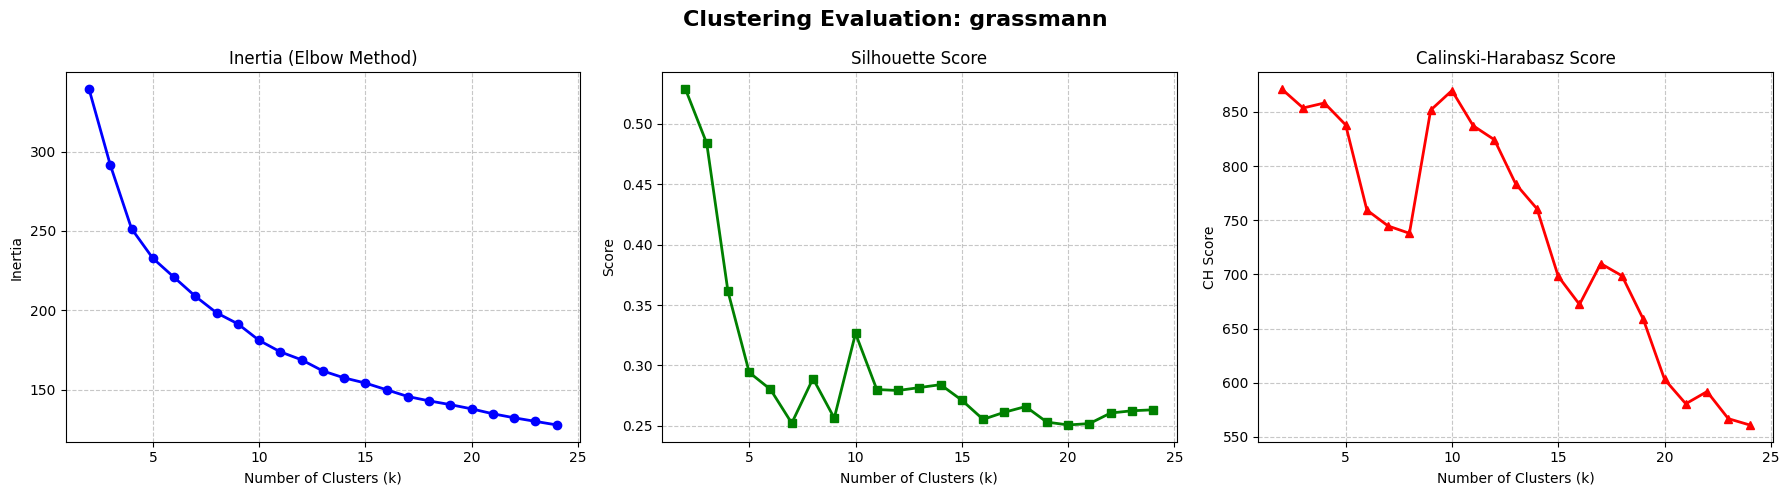

Evaluating euclidean_riemann...


/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:383: UserWarning: Explicit initial positions passed: performing only one init of the MDS instead of 2
  warnings.warn(


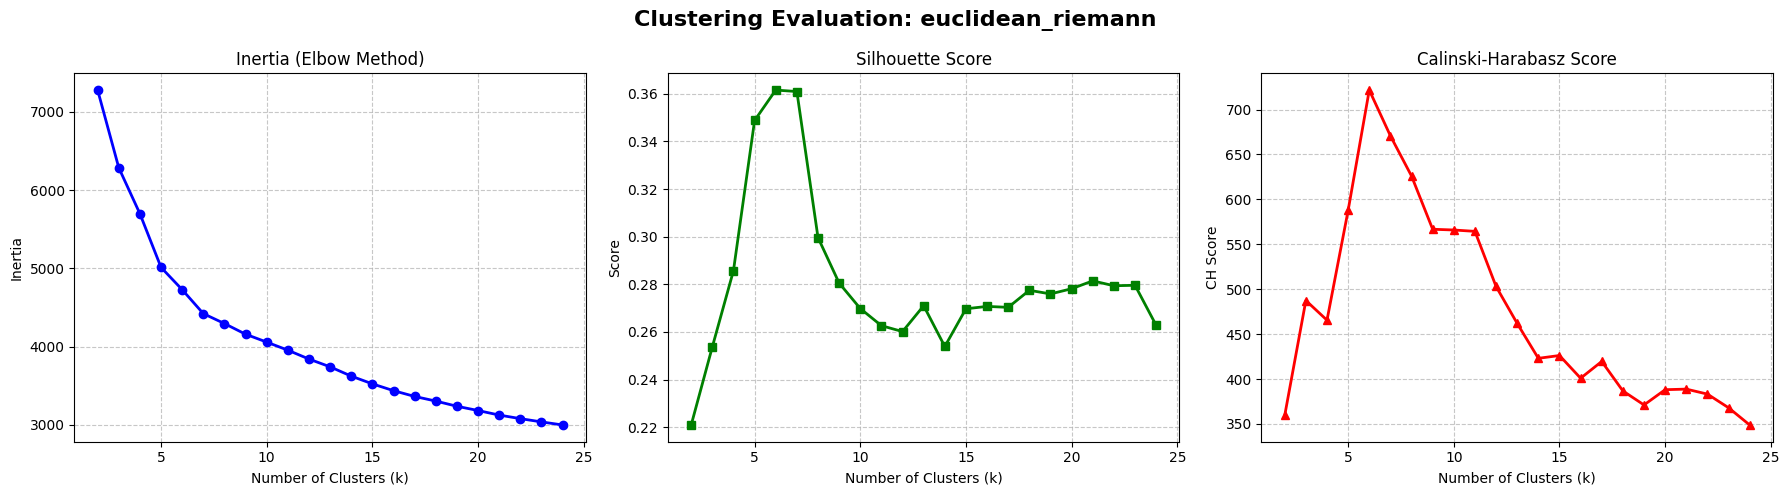

Evaluating affine_riemann...


/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:383: UserWarning: Explicit initial positions passed: performing only one init of the MDS instead of 2
  warnings.warn(


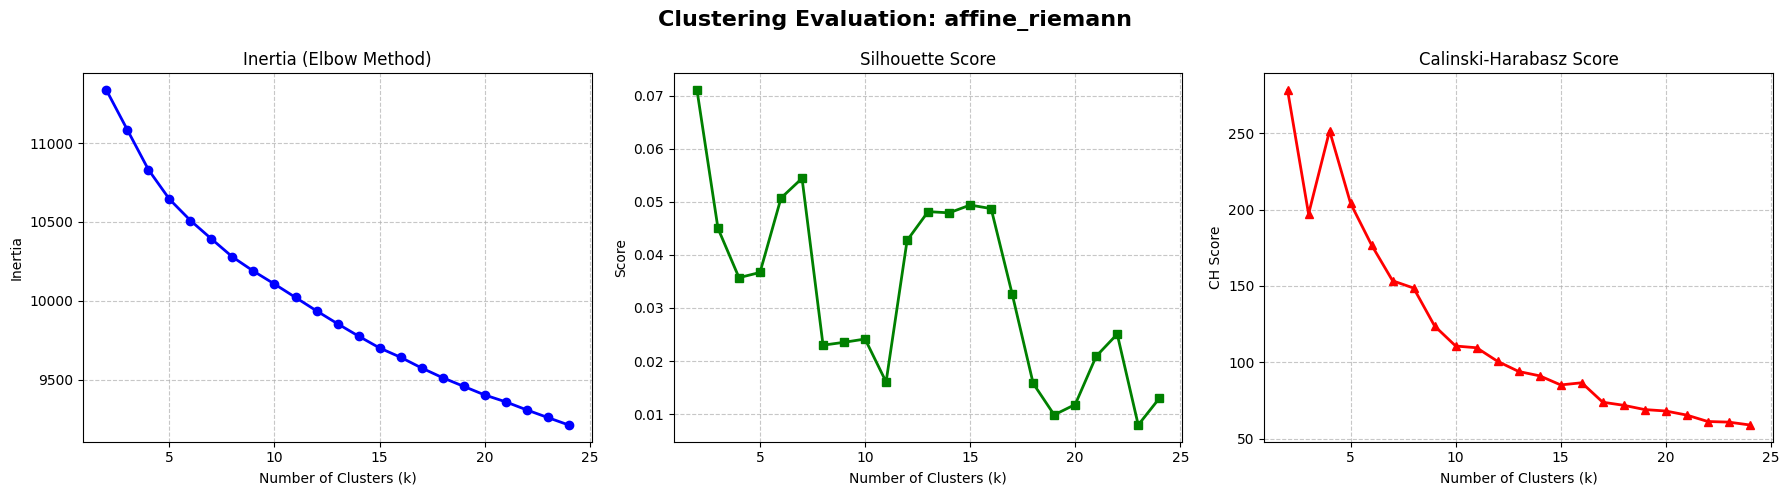

Evaluating wasserstein...


/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:383: UserWarning: Explicit initial positions passed: performing only one init of the MDS instead of 2
  warnings.warn(


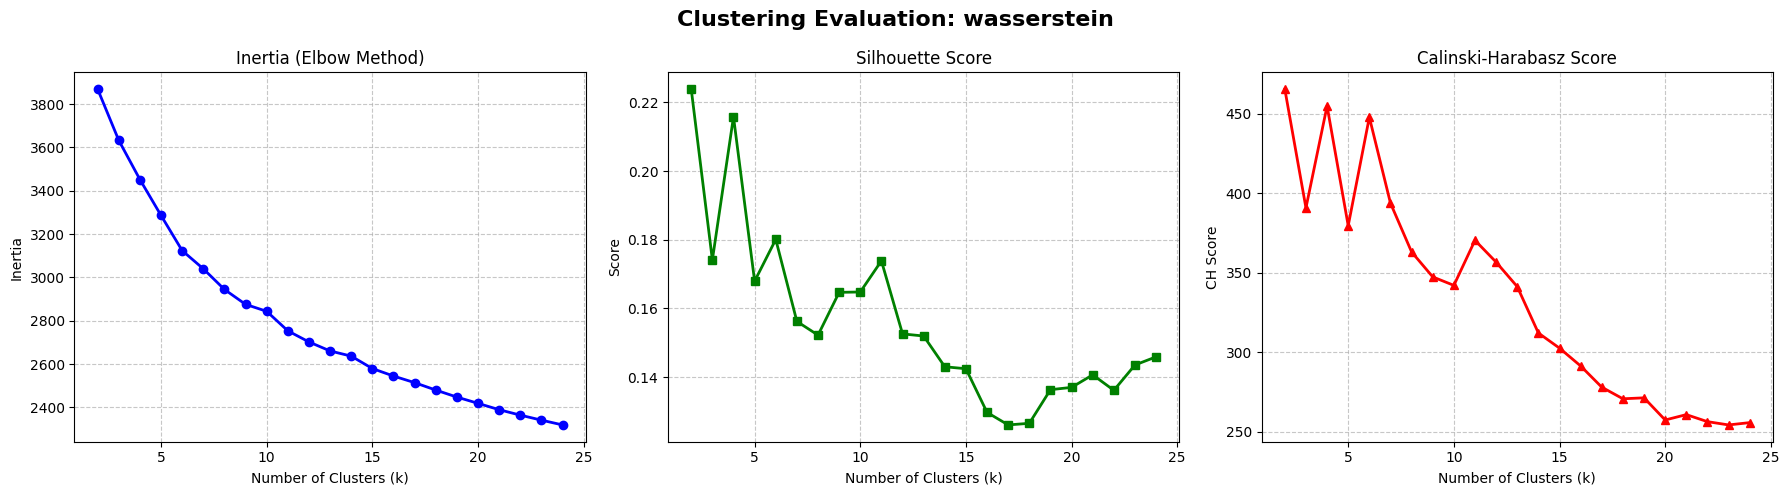

In [9]:
cluster_number(dist_matrices, max_k=25)

# best number of clusters
- grassmann: 14 - ideally around 650...
- riemann euclidean: 3
- riemann affine: 2 or 6
- wasserstein: 4

In [10]:
def plot_materials_clustering(mp_df: pl.DataFrame, dist_matrix: np.ndarray, metric_name="wasserstein", num_clusters=4):
    """
    Clusters materials using a precomputed distance matrix and generates a Chemiscope visualization.
    """
    print(f"Using precomputed '{metric_name}' distance matrix (Shape: {dist_matrix.shape})")

    model = kmedoids.KMedoids(n_clusters=num_clusters, metric='precomputed', random_state=42)
    clusters = model.fit_predict(dist_matrix)

    counts = Counter(clusters)
    print("\nCluster Distribution:")
    for i in range(num_clusters):
        print(f" - Cluster {i}: {counts[i]} materials")

    # 2. Dimensionality Reduction (t-SNE on distance matrix)
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, metric="precomputed", init="random")
    X_tsne = tsne.fit_transform(dist_matrix)

    reducer = UMAP(n_neighbors=15, min_dist=0.1, n_components=2, metric="precomputed", random_state=42)
    X_umap = reducer.fit_transform(dist_matrix)

    mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42, normalized_stress='auto')
    X_pca = mds.fit_transform(dist_matrix)

    # 3. Add results and formatted strings to the Polars DataFrame
    df = mp_df.with_columns(
        pl.Series("cluster", clusters),
        pl.format("a: {}, b: {}, c: {}", 
                  pl.col("a").round(3), 
                  pl.col("b").round(3), 
                  pl.col("c").round(3)).alias("lattice_str")
    )

    df = df.with_columns(
        pl.Series("cluster", clusters),
        pl.format("alpha: {}, beta: {}, gamma: {}", 
                  pl.col("alpha").round(3), 
                  pl.col("beta").round(3), 
                  pl.col("gamma").round(3)).alias("angles_str")
    )

    # 4. Generate the Summary Table (using Polars)
    summary_table = (
        df.group_by("cluster")
        .agg([
            pl.len().alias("total_materials"),
            pl.col("formula_pretty").n_unique().alias("unique_formulas"),
            # Use .drop_nulls().first() to avoid errors if a cluster has mixed types
            pl.col("crystal_system").drop_nulls().mode().first().alias("dominant_crystal_system"),
            pl.col("space_group").drop_nulls().mode().first().alias("dominant_space_group"),
            pl.col("energy_per_atom").mean().round(3).alias("mean_energy_per_atom"),
            pl.col("density").mean().round(3).alias("mean_density")
        ])
        .sort("cluster")
    )

    pl.Config.set_fmt_str_lengths(100)
    print("\nCluster Composition Summary:")
    display(summary_table)

    # 5. Prepare ASE Frames for Chemiscope
    frames = []
    for s_str in df["raw_structure"]:
        pmg = Structure.from_dict(json.loads(s_str))
        frames.append(AseAtomsAdaptor.get_atoms(pmg))

    # 6. Define Properties Dictionary mapping Polars columns
    properties = {
        "Cluster": clusters.astype(int),
        "t-SNE 1": X_tsne[:, 0],
        "t-SNE 2": X_tsne[:, 1],
        "Material ID": df["material_id"].to_list(),
        "Formula": df["formula_pretty"].to_list(),
        "Crystal System": df["crystal_system"].to_list(),
        "Space Group": df["space_group"].to_list(),
        "Energy per Atom": df["energy_per_atom"].to_numpy(),
        "Formation Energy": df["formation_energy_per_atom"].to_numpy(),
        "Density": df["density"].to_numpy(),
        "Volume": df["volume"].to_numpy(),
        "Lattice (a,b,c)": df["lattice_str"].to_list(),
        "Angles (alpha, beta, gamma)" : df["angles_str"].to_list(),
    }
    
    # Safely add weight if you calculated it previously
    if "weight" in df.columns:
        properties["Weight"] = df["weight"].to_numpy()

    # 7. Chemiscope Settings and Export
    os.makedirs("report/materials_project/figures", exist_ok=True)
    output_path = f"report/materials_project/figures/chemiscope_{metric_name}_k{num_clusters}.json.gz"

    settings = {
        "map": {
            "x": {"property": "t-SNE 1"},
            "y": {"property": "t-SNE 2"},
            "color": {"property": "Cluster"},
            "size": {"factor": 35}
        },
        "structure": [{"unitcell": True, "keepOrientation": True}]
    }

    chemiscope.write_input(
        path=output_path,
        structures=frames,
        properties=properties,
        settings=settings,
        metadata={
            "name": f"MP Clustering ({metric_name})",
            "description": f"KMedoids (k={num_clusters}) using {metric_name} distance matrix."
        }
    )

    print(f"\nChemiscope file successfully saved to: {output_path}")

    plot_cluster(X_tsne, clusters, title="Cluster Projection T-SNE")
    plot_cluster(X_pca, clusters, title="Cluster Projection PCA")
    plot_cluster(X_umap, clusters, title="Cluster Projection UMAP")

    return summary_table, output_path

def plot_cluster(X_2d: np.ndarray, clusters: np.ndarray, title: str = "Clustering Projection"):
    """
    Plots a 2D projection (like t-SNE or UMAP) colored by cluster labels nicely.
    
    Args:
        X_2d: A 2D numpy array of shape (n_samples, 2) containing the projection coordinates.
        clusters: A 1D array of cluster labels.
        title: The title of the plot.
    """
    plt.figure(figsize=(10, 8))
    
    # Use seaborn for a nice aesthetic
    sns.set_theme(style="whitegrid")
    
    # Create the scatter plot
    scatter = sns.scatterplot(
        x=X_2d[:, 0], 
        y=X_2d[:, 1], 
        hue=clusters, 
        palette="deep",    # A visually pleasing color palette
        s=80,              # Size of the dots
        alpha=0.8,         # Slight transparency to handle overlaps
        edgecolor="w",     # White border around dots
        linewidth=0.5
    )
    
    # Customize titles and labels
    plt.title(title, fontsize=16, fontweight='bold', pad=15)
    plt.xlabel("Component 1", fontsize=12)
    plt.ylabel("Component 2", fontsize=12)
    
    # Position the legend outside the plot
    plt.legend(title="Cluster ID", bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
    
    # Ensure nothing gets cut off
    plt.tight_layout()
    plt.show()


# Grassmann

Using precomputed 'grassmann' distance matrix (Shape: (1000, 1000))

Cluster Distribution:
 - Cluster 0: 790 materials
 - Cluster 1: 210 materials


/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materi


Cluster Composition Summary:


cluster,total_materials,unique_formulas,dominant_crystal_system,dominant_space_group,mean_energy_per_atom,mean_density
u64,u32,u32,str,str,f64,f64
0,790,785,"""Monoclinic""","""P2_1/c""",-6.634,4.998
1,210,209,"""Cubic""","""Pm-3m""",-6.506,6.007



Chemiscope file successfully saved to: report/materials_project/figures/chemiscope_grassmann_k2.json.gz


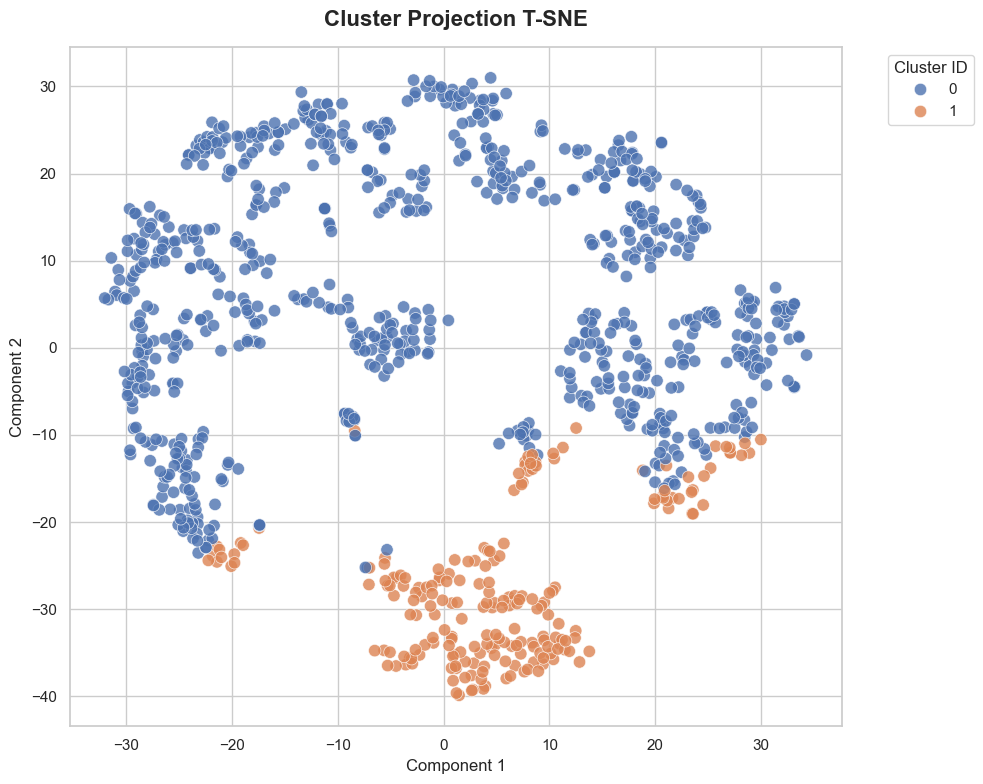

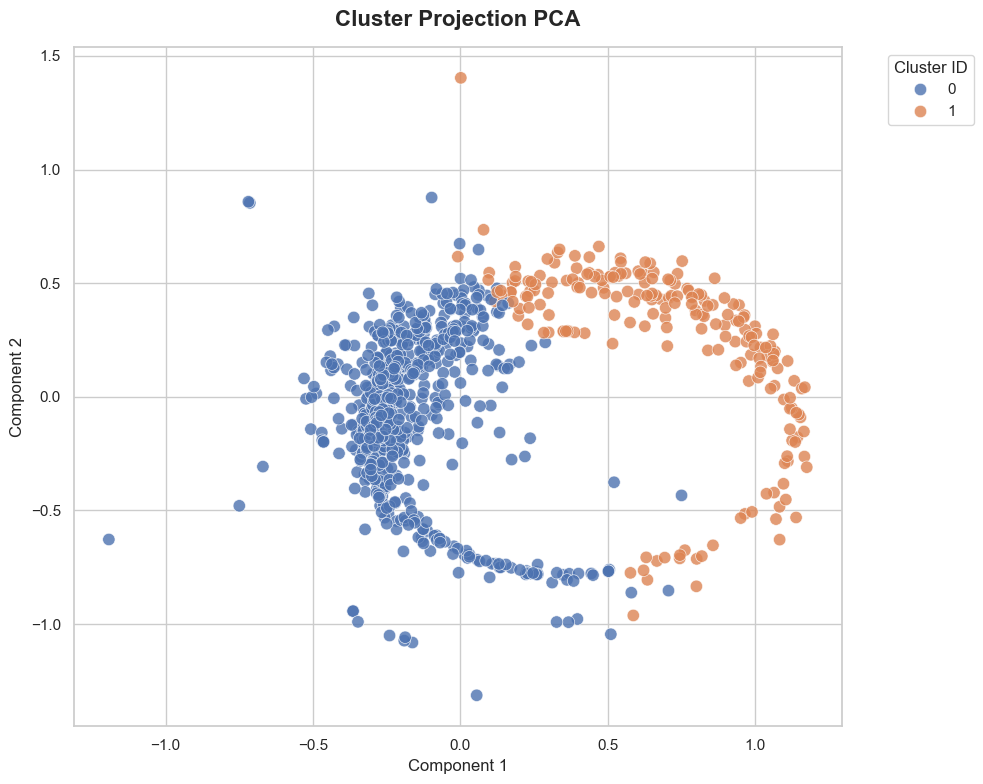

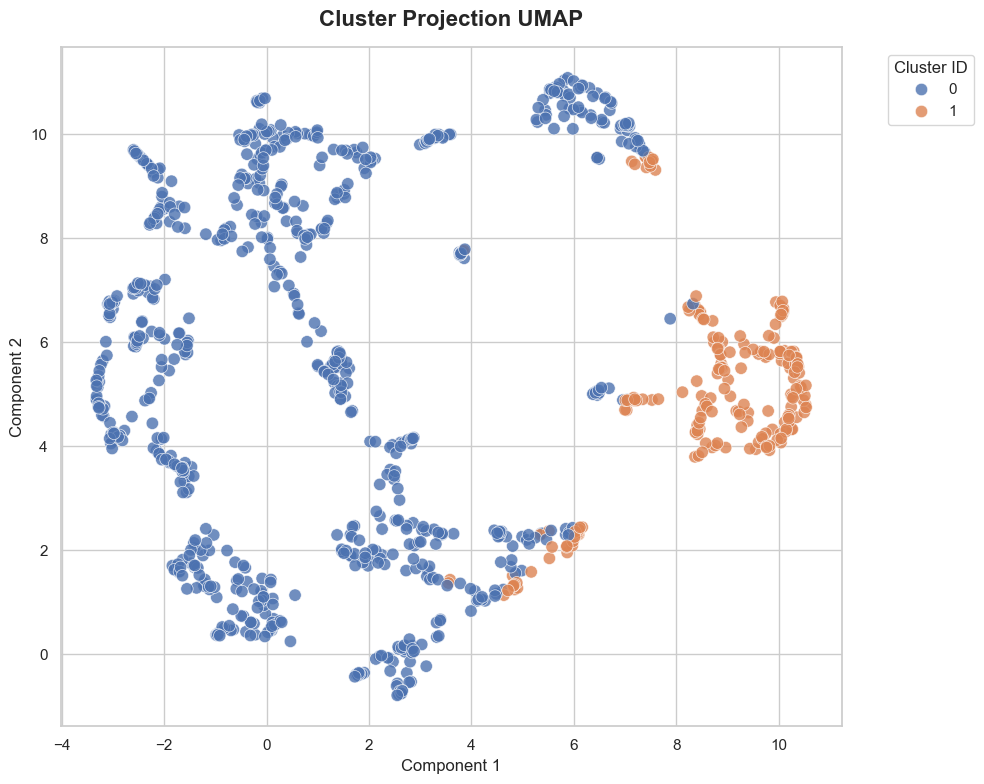

In [11]:
summary_table, output_path = plot_materials_clustering(mp.df, 
                                                       dist_matrix = dist_matrices['grassmann'], 
                                                       num_clusters=2, 
                                                       metric_name='grassmann'
                                                       )

In [12]:
chemiscope.show_input(output_path)

<ChemiscopeWidget(meta={'name': 'MP Clustering (grassmann)', 'description': 'KMedoids (...}, settings={'map': …

# Riemann

Using precomputed 'euclidean_riemann' distance matrix (Shape: (1000, 1000))

Cluster Distribution:
 - Cluster 0: 50 materials
 - Cluster 1: 260 materials
 - Cluster 2: 128 materials
 - Cluster 3: 261 materials
 - Cluster 4: 156 materials
 - Cluster 5: 145 materials


/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The 


Cluster Composition Summary:


cluster,total_materials,unique_formulas,dominant_crystal_system,dominant_space_group,mean_energy_per_atom,mean_density
u64,u32,u32,str,str,f64,f64
0,50,50,"""Cubic""","""Pm-3m""",-6.833,6.589
1,260,260,"""Monoclinic""","""P2_1/c""",-5.856,4.15
2,128,128,"""Trigonal""","""Ia-3""",-7.415,5.926
3,261,259,"""Monoclinic""","""P2_1/c""",-6.991,6.135
4,156,155,"""Monoclinic""","""R-3m""",-6.125,5.186
5,145,142,"""Monoclinic""","""P2_1/c""",-6.991,4.361



Chemiscope file successfully saved to: report/materials_project/figures/chemiscope_euclidean_riemann_k6.json.gz


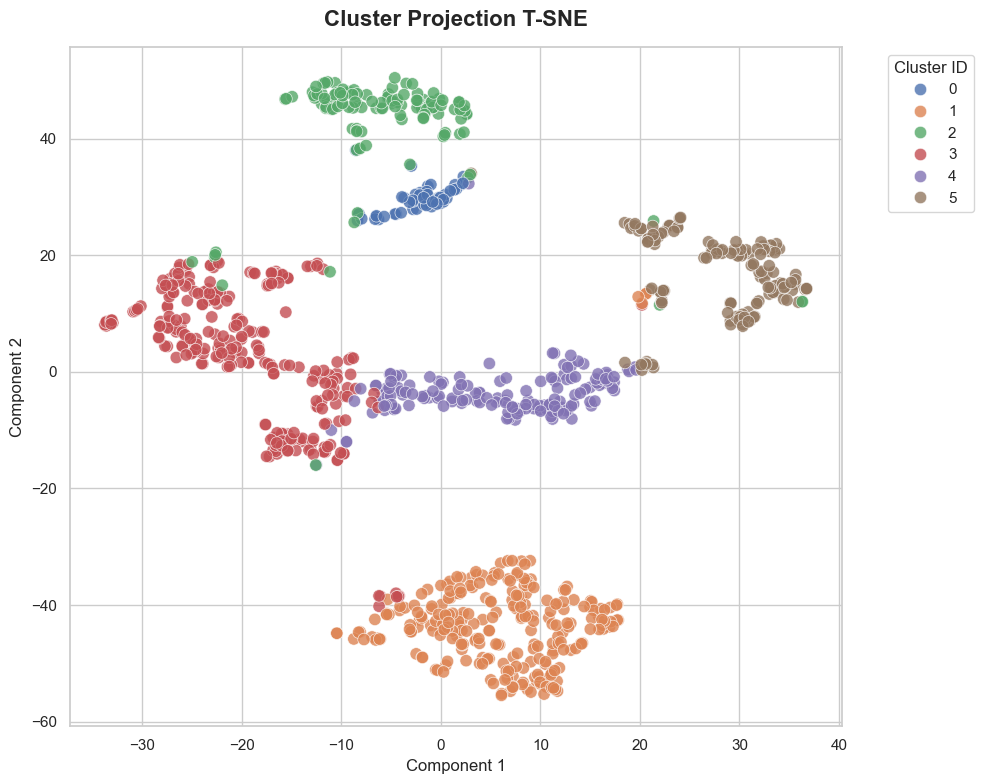

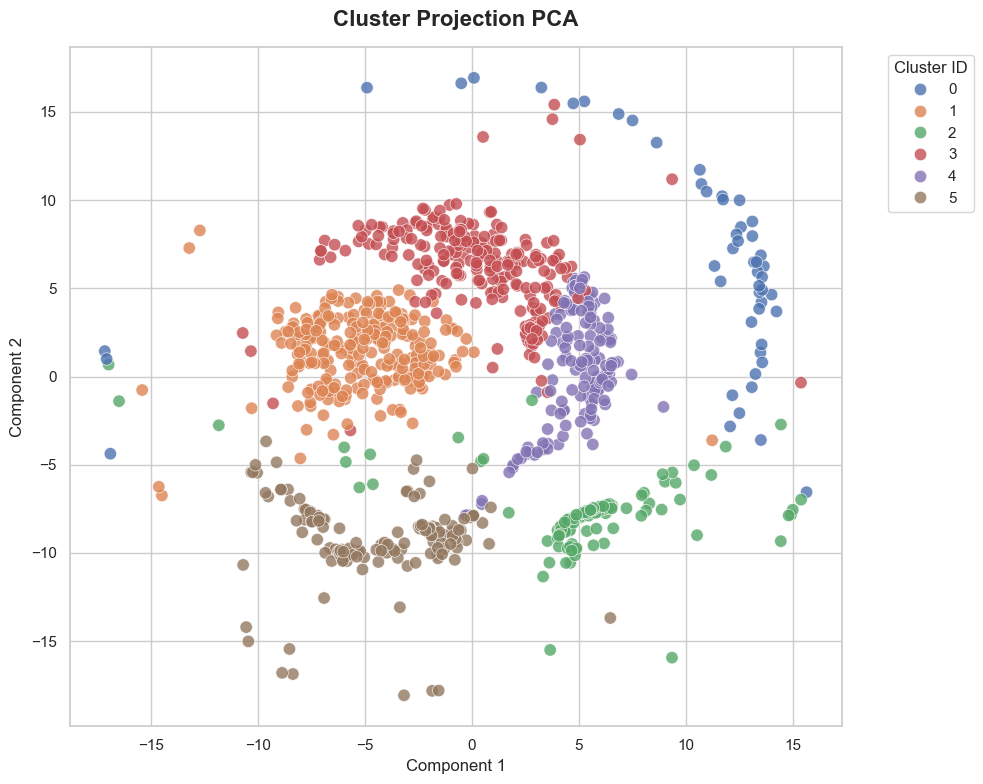

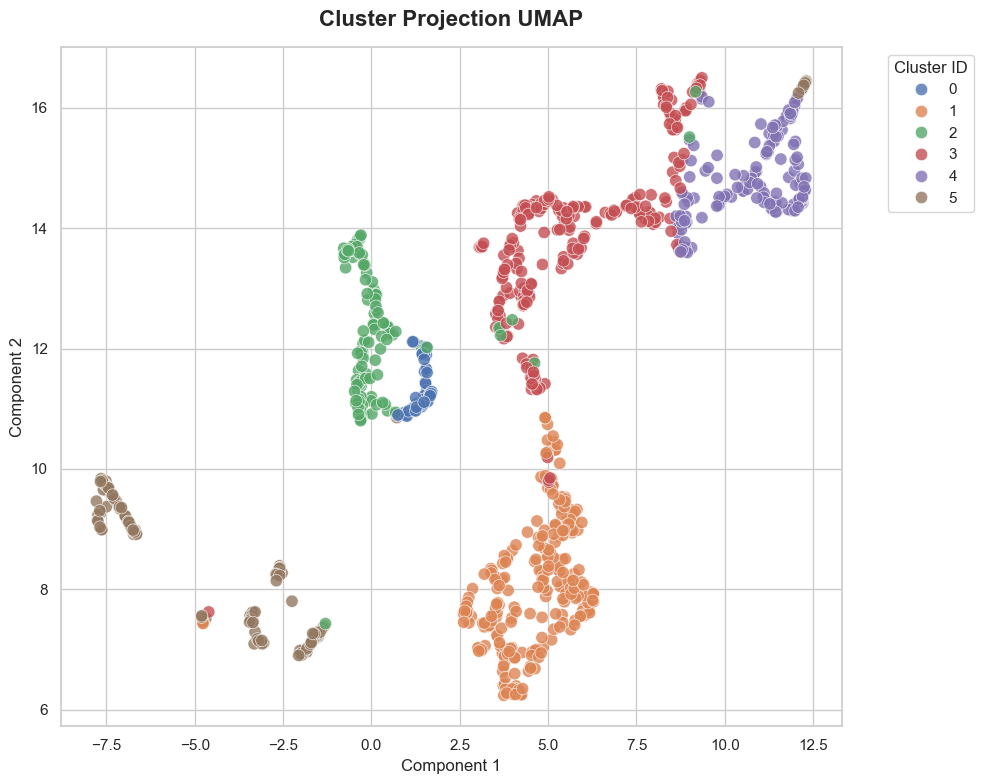

In [13]:
summary_table, output_path = plot_materials_clustering(mp.df, 
                                                       dist_matrix = dist_matrices['euclidean_riemann'], 
                                                       num_clusters=6, 
                                                       metric_name='euclidean_riemann'
                                                       )

In [14]:
chemiscope.show_input(output_path)

<ChemiscopeWidget(meta={'name': 'MP Clustering (euclidean_riemann)', 'description': 'KM...}, settings={'map': …

Using precomputed 'riemann_affine' distance matrix (Shape: (1000, 1000))

Cluster Distribution:
 - Cluster 0: 258 materials
 - Cluster 1: 172 materials
 - Cluster 2: 213 materials
 - Cluster 3: 229 materials
 - Cluster 4: 128 materials


/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The 


Cluster Composition Summary:


cluster,total_materials,unique_formulas,dominant_crystal_system,dominant_space_group,mean_energy_per_atom,mean_density
u64,u32,u32,str,str,f64,f64
0,258,256,"""Monoclinic""","""P2_1/c""",-6.214,3.552
1,172,172,"""Monoclinic""","""P2_1/c""",-6.11,6.863
2,213,212,"""Orthorhombic""","""Pm-3m""",-6.427,5.499
3,229,228,"""Monoclinic""","""P2_1/c""",-6.225,4.386
4,128,126,"""Trigonal""","""P-3m1""",-9.05,7.32



Chemiscope file successfully saved to: report/materials_project/figures/chemiscope_riemann_affine_k5.json.gz


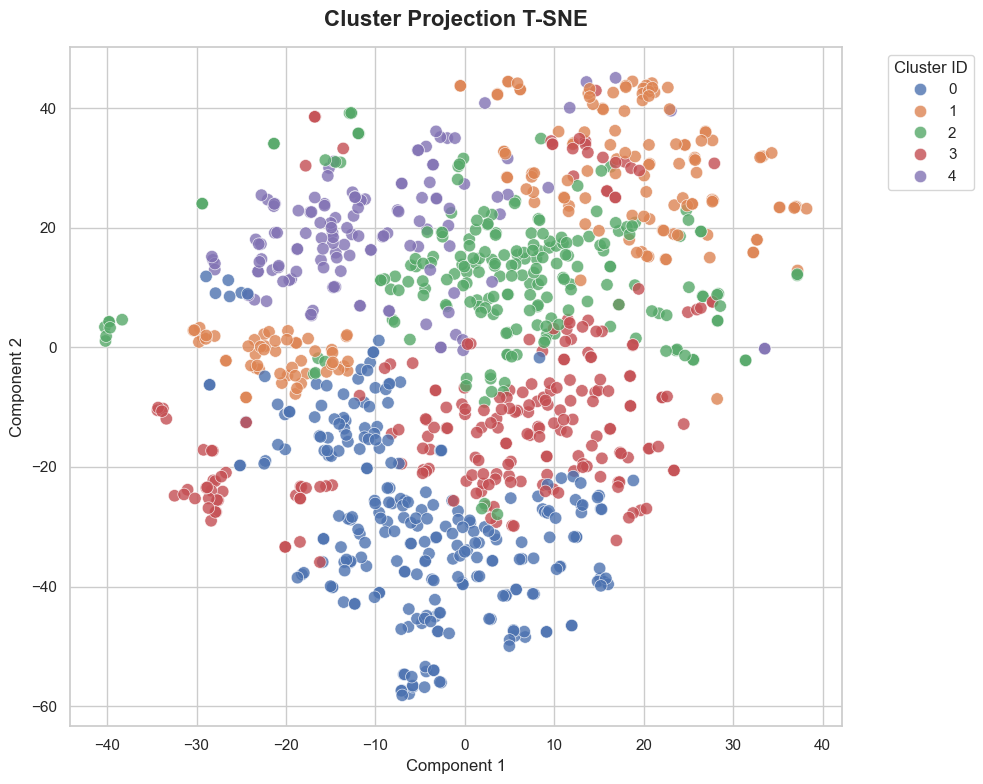

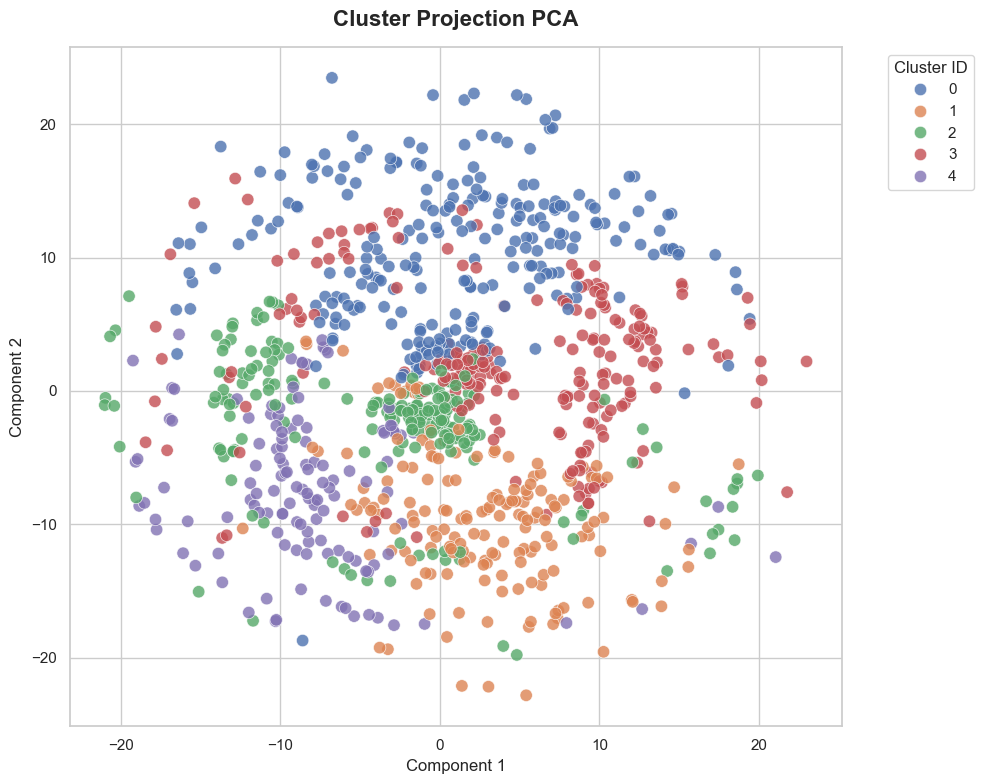

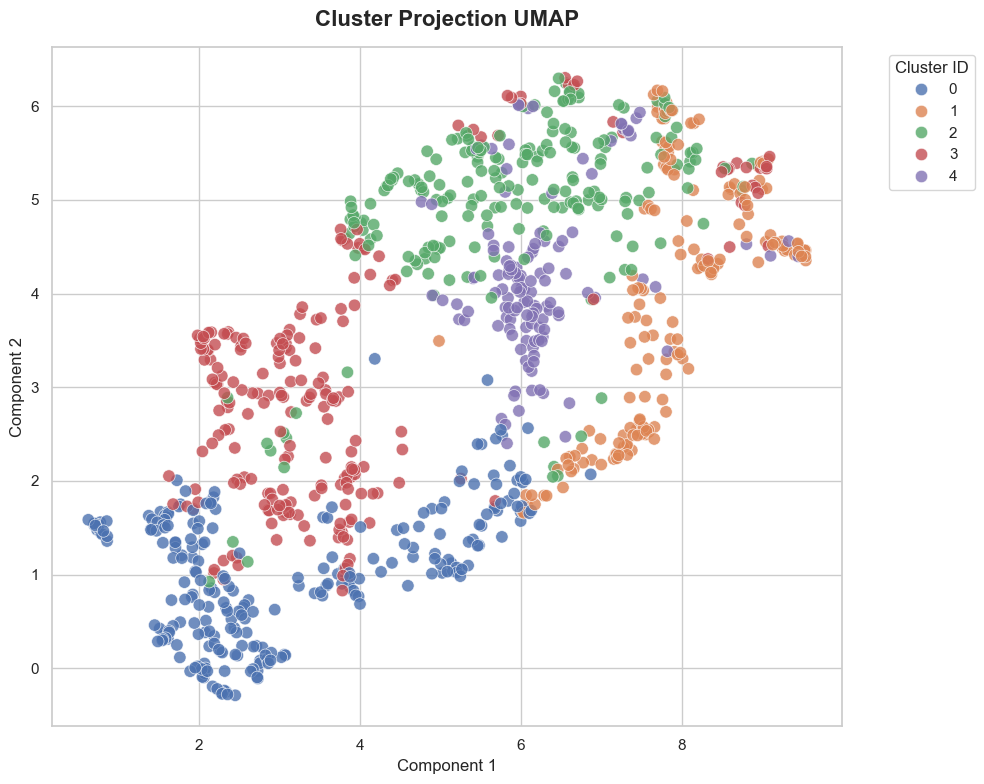

In [15]:
summary_table, output_path = plot_materials_clustering(mp.df, 
                                                       dist_matrix = dist_matrices['affine_riemann'], 
                                                       num_clusters=5, 
                                                       metric_name='riemann_affine'
                                                       )

In [16]:
chemiscope.show_input(output_path)

<ChemiscopeWidget(meta={'name': 'MP Clustering (riemann_affine)', 'description': 'KMedo...}, settings={'map': …

# Wasserstein

Using precomputed 'wasserstein' distance matrix (Shape: (1000, 1000))

Cluster Distribution:
 - Cluster 0: 54 materials
 - Cluster 1: 226 materials
 - Cluster 2: 516 materials
 - Cluster 3: 204 materials


/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The 


Cluster Composition Summary:


cluster,total_materials,unique_formulas,dominant_crystal_system,dominant_space_group,mean_energy_per_atom,mean_density
u64,u32,u32,str,str,f64,f64
0,54,54,"""Trigonal""","""R-3m""",-6.964,5.47
1,226,224,"""Cubic""","""Pm-3m""",-6.926,5.939
2,516,513,"""Monoclinic""","""P4/nmm""",-6.762,5.273
3,204,204,"""Monoclinic""","""P2_1/c""",-5.77,4.172



Chemiscope file successfully saved to: report/materials_project/figures/chemiscope_wasserstein_k4.json.gz


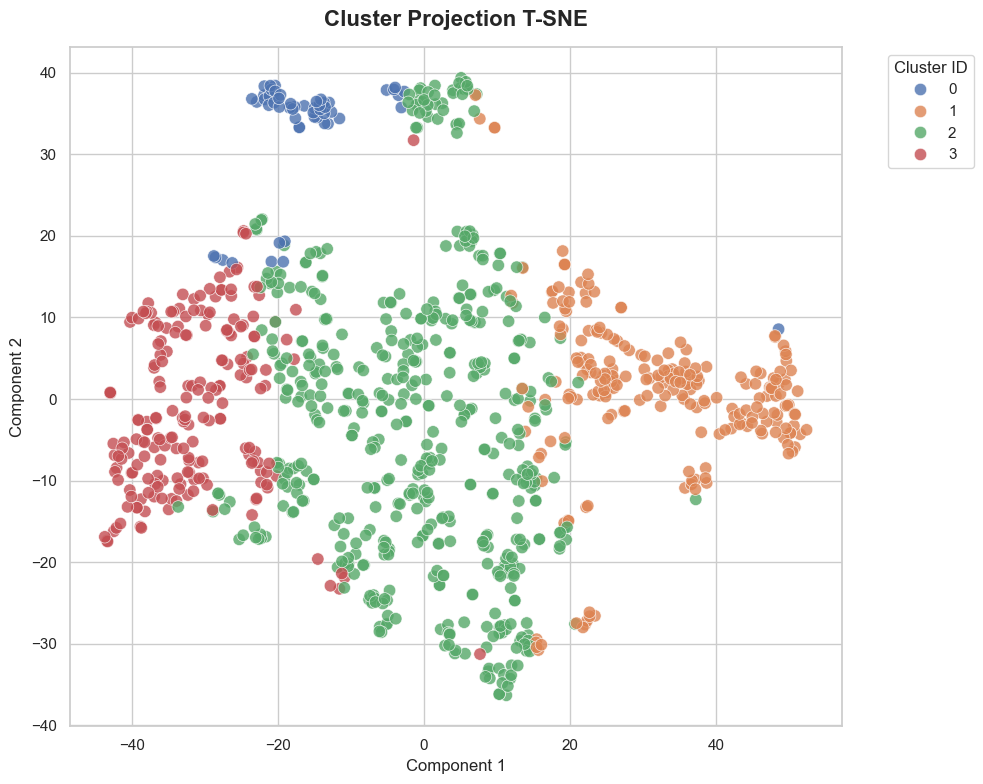

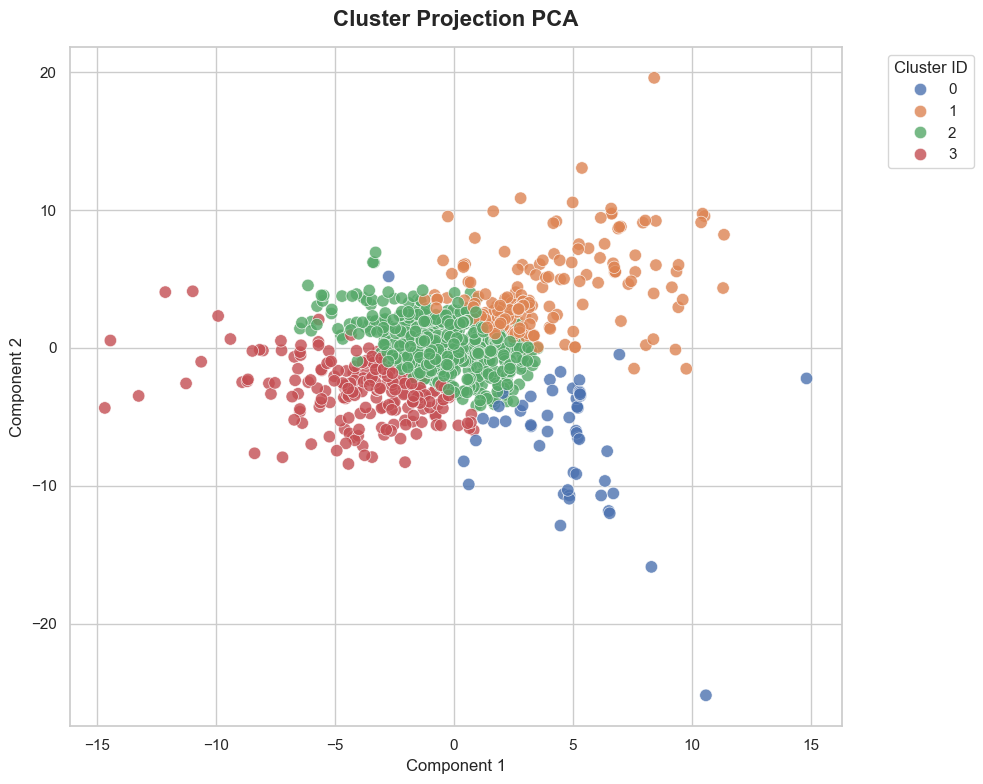

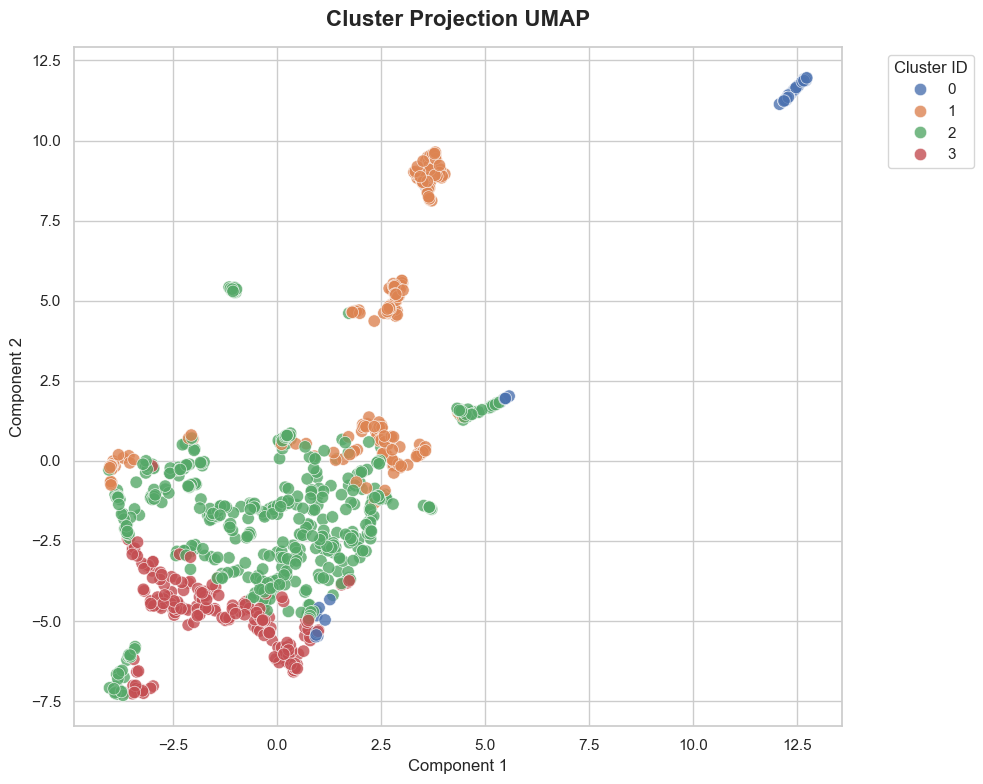

In [17]:
summary_table, output_path = plot_materials_clustering(mp.df, 
                                                       dist_matrix = dist_matrices['wasserstein'], 
                                                       num_clusters=4, 
                                                       metric_name='wasserstein'
                                                       )

In [18]:
chemiscope.show_input(output_path)

<ChemiscopeWidget(meta={'name': 'MP Clustering (wasserstein)', 'description': 'KMedoids...}, settings={'map': …